In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')

import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model

### Define the model — Gaussian case

We consider the time-varying AR(1) model
$$
y_t = c(t) + \Phi(t)\, y_{t-1} + \varepsilon_t,
\qquad
\varepsilon_t \sim \mathcal{N}(0,\sigma^2(t)).
$$

Here:
- $y_t$ is the observed value at time $t$,
- $c(t)$ is the time-dependent intercept,
- $\Phi(t)$ is the time-dependent autoregressive coefficient,
- $\sigma^2(t)$ is the time-dependent conditional variance,
- $\varepsilon_t$ is the Gaussian innovation term.

The goal is to estimate the functions $c(t)$, $\Phi(t)$, and $\sigma^2(t)$ from data.

In [ ]:
def c(t):
    return np.sin(t/(6.0*np.pi)) + 7.0

def phi(t):
    return - 0.3*(0.5* np.cos(t/(4.0*np.pi) + 30.0) + 0.5) + 0.2

def sigma_v(t):
  return 0.5*np.abs(0.5+np.sin(t/(6.0*np.pi))) + 0.5

In [ ]:
# Data generation

# CASE 3 - variable c, phi, sigma

def generate_ar1_data_3(n=100, seed=42, y_0=7.0):
    np.random.seed(seed)

    t = np.linspace(0, n-1, n)
    y = np.zeros(n)

    y[0] = y_0

    for i in range(1, n):
        epsilon = np.random.normal(0, sigma_v(t[i]), 1).item()
        y[i] = c(t[i]) + phi(t[i]) * y[i-1] + epsilon

    return t, y

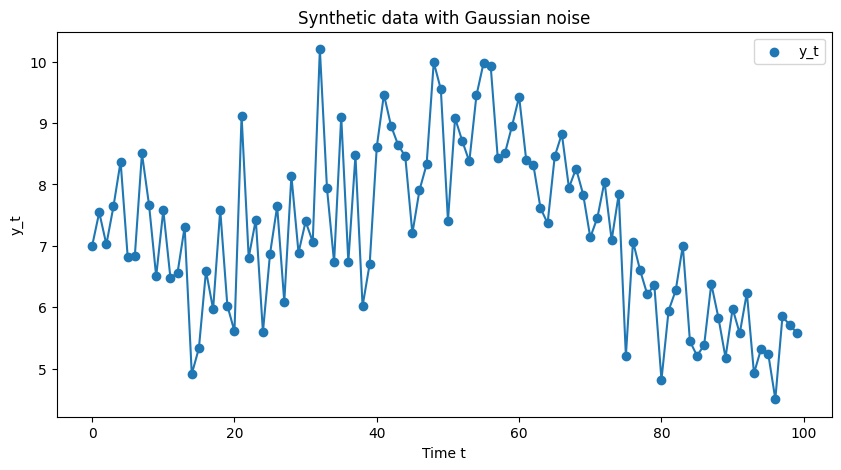

In [ ]:
t, y3 = generate_ar1_data_3()

# Data visualization
plt.figure(figsize=(10, 5))
plt.scatter(t, y3, label="y_t", marker = 'o')
plt.plot(t, y3)
plt.xlabel("Time t")
plt.ylabel("y_t")
plt.title("Synthetic data with Gaussian noise")
plt.savefig("dane3.png")
plt.legend()
plt.show()

In [ ]:
def loss3(y_true, y_pred): #neural network returns c, phi, ln(sigma^2)

  N = tf.shape(y_true)[0] - 1
  y_true_1 = tf.slice(y_true, [1,0], [N,1]) #indices from 1 to N; size = N
  y_true_2 = tf.slice(y_true, [0,0], [N,1]) #indices from 0 to N-1, size = N

  c = tf.slice(y_pred,[1,0],[N,1]) #from 1 to N
  phi = tf.slice(y_pred,[1,1],[N,1]) #from 1 to N
  ln_sigma_squared = tf.slice(y_pred,[1,2],[N,1]) #from 1 to N
  sigma_squared = tf.exp(ln_sigma_squared)

  a = tf.square(y_true_1 - c - phi*y_true_2)
  b = a/sigma_squared

  loss = tf.reduce_sum(ln_sigma_squared + b, axis=0)

  return loss/2

In [ ]:
model3 =  Sequential()
model3.add(Input(shape=(1,)))
model3.add(Dense(16, activation='gelu'))
model3.add(Dense(32, activation='gelu'))
model3.add(Dense(16, activation='gelu'))
model3.add(Dense(3, activation='linear'))

model3.compile(loss=loss3,optimizer="adam")

# summarize model along with number of model weights
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,155 (4.51 KB)

 Trainable params: 1,155 (4.51 KB)

 Non-trainable params: 0 (0.00 B)

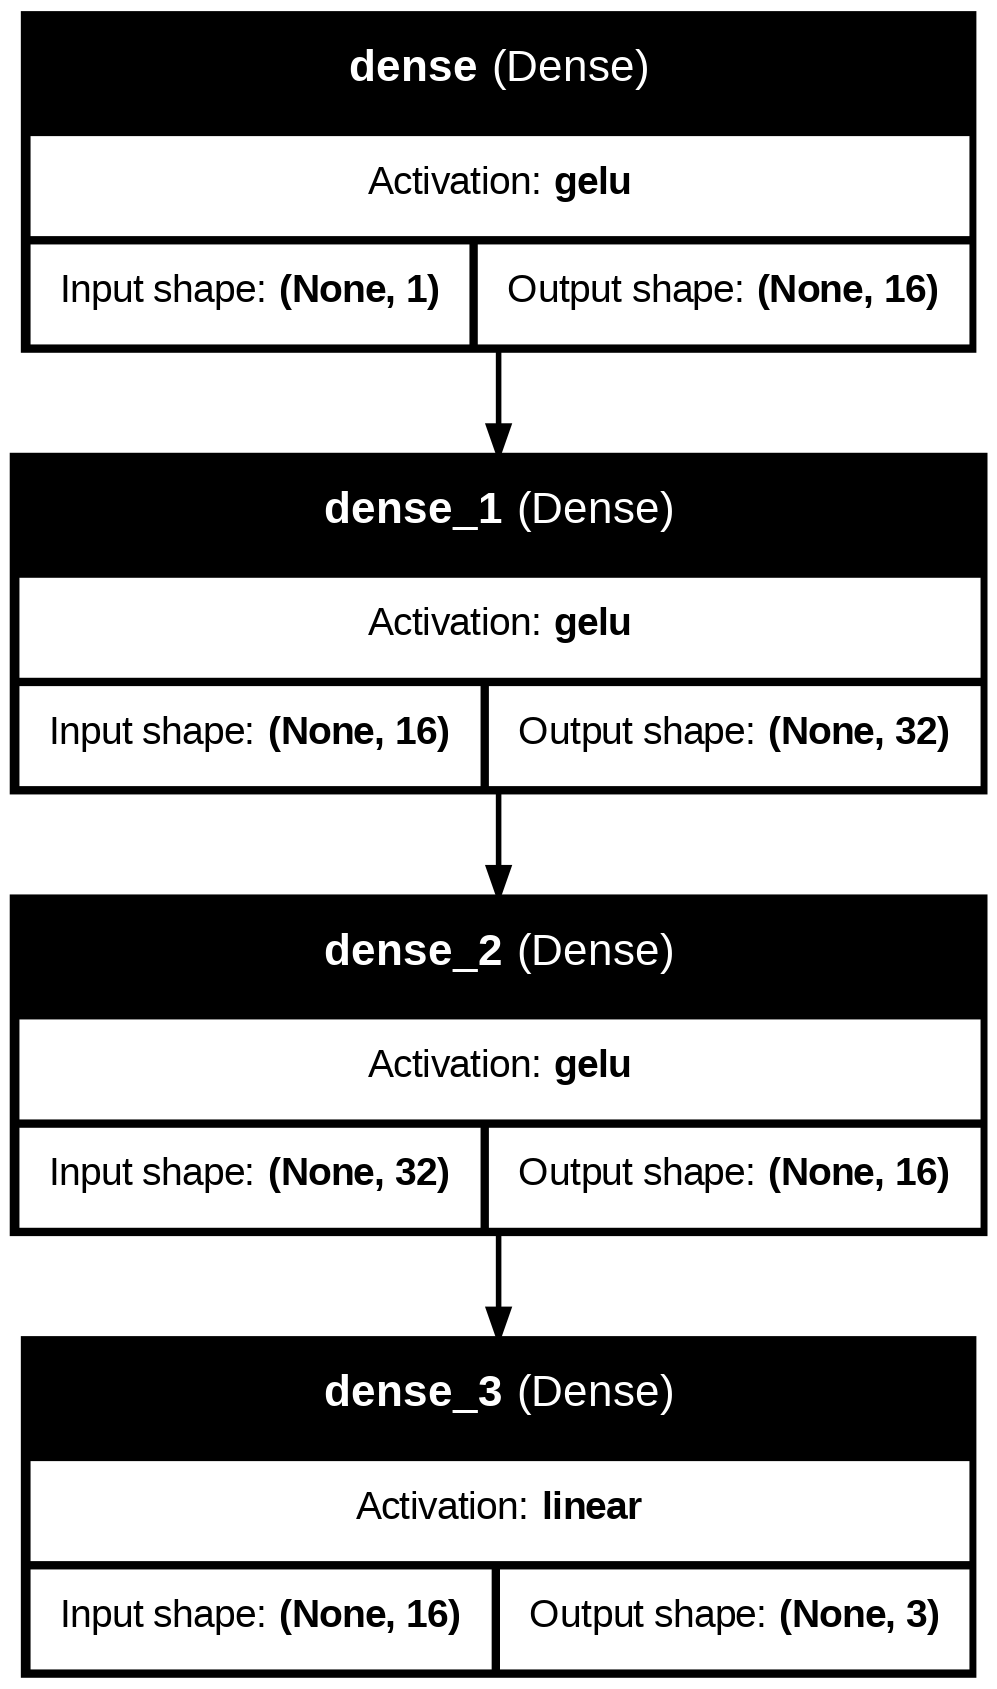

In [ ]:
plot_model(model3, show_shapes=True, show_layer_names=True, show_layer_activations=True)

In [ ]:
y_3 = np.array([y3]).T
y_3 = y_3.astype("float32")

In [ ]:
t = t.astype("float32")
tn = (t - t.min(axis=0)) / (t.max(axis=0) - t.min(axis=0))

In [ ]:
history=model3.fit(tn, y_3,
                  batch_size=16,
                  epochs=2500,
                  verbose=1,
                  shuffle = False
                 )

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 381.5462
Epoch 2/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 338.6782 
Epoch 3/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 295.9393  
Epoch 4/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 250.8060 
Epoch 5/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 202.8248 
Epoch 6/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 152.9527 
Epoch 7/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 104.3051 
Epoch 8/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 63.2318  
Epoch 9/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 38.4427 
Epoch 10/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.5688 
Epoch 11/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.9905 
Epoch 12/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.0340 
Epoch 13/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.9737 
Epoch 14/2500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.43

In [ ]:
prediction = model3.predict(tn)

file = open('case3_result', 'wb')
pickle.dump(prediction, file)
file.close()

pred_c = prediction[:,0]
pred_phi=prediction[:,1]
pred_sigma_squared=np.exp(prediction[:,2])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


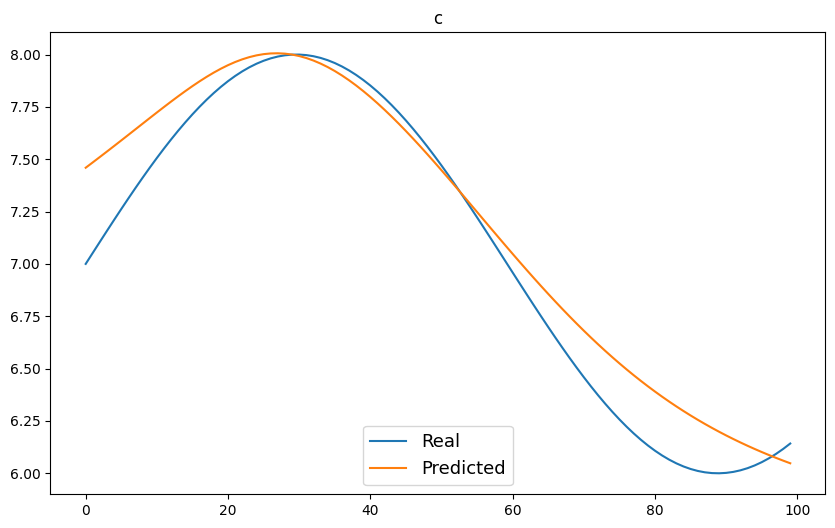

In [ ]:
plt.figure(figsize=(10, 6))

t1 = np.linspace(0, 99, 100)

c_value = c(0) if np.isscalar(c(t1)) else c(t1)
c_theoretical = np.full_like(t1, c_value) if np.isscalar(c_value) else c_value

plt.plot(t, c_theoretical, linewidth=1.5, label = 'Real')
plt.plot(t, pred_c, linewidth=1.5, label = 'Predicted')
plt.title('c')
plt.legend(loc ="lower center", fontsize="13")
plt.savefig("case3_c.png")
plt.show()

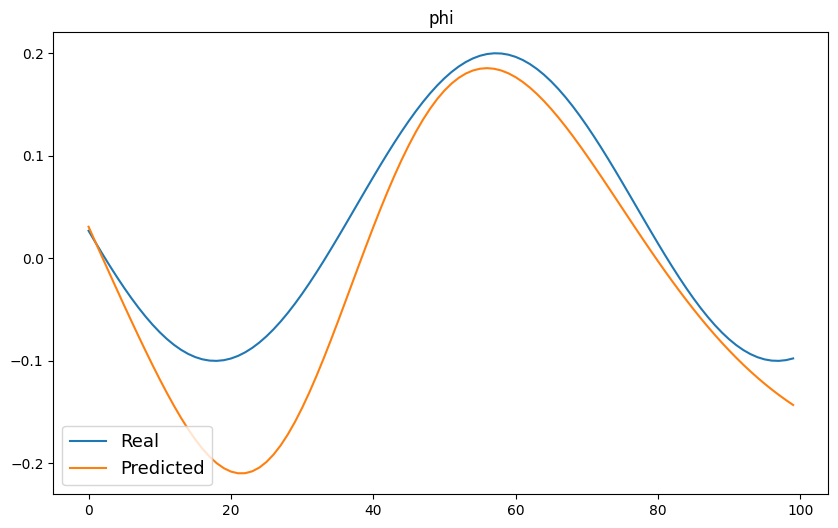

In [ ]:
plt.figure(figsize=(10, 6))

phi_value = phi(0) if np.isscalar(phi(t1)) else phi(t1)
phi_theoretical = np.full_like(t1, phi_value) if np.isscalar(phi_value) else phi_value

plt.plot(t, phi_theoretical, linewidth=1.5, label = 'Real')
plt.plot(t, pred_phi, linewidth=1.5, label = 'Predicted')
plt.title('phi')
plt.legend(loc ="lower left", fontsize="13")
plt.savefig("case3_phi.png")
plt.show()

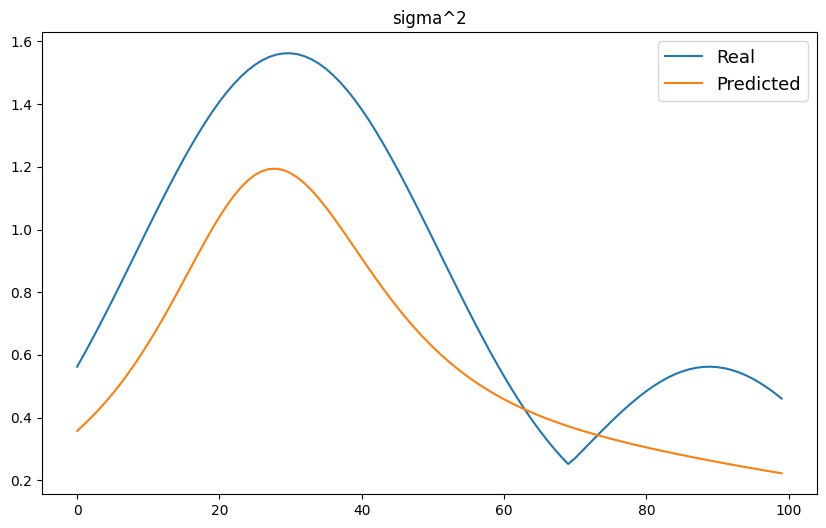

In [ ]:
plt.figure(figsize=(10, 6))

sigma_squared_value = np.square(sigma_v(0)) if np.isscalar(np.square(sigma_v(t1))) else np.square(sigma_v(t1))
sigma_squared_theoretical = np.full_like(t1, sigma_squared_value) if np.isscalar(sigma_squared_value) else sigma_squared_value

plt.plot(t, sigma_squared_theoretical, linewidth=1.5, label = 'Real')
plt.plot(t, pred_sigma_squared, linewidth=1.5, label = 'Predicted')
plt.title('sigma^2')
plt.legend(loc ="upper right", fontsize="13")
plt.savefig("case3_sigma_squared.png")
plt.show()

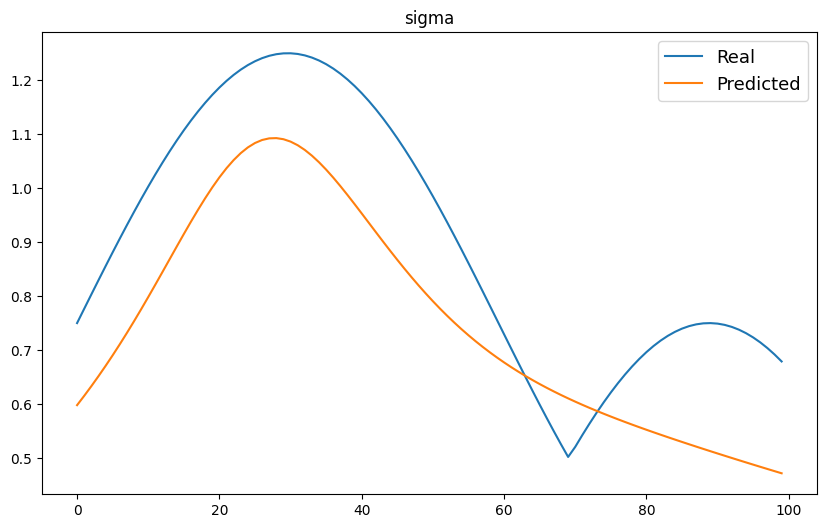

In [ ]:
plt.figure(figsize=(10, 6))

sigma_value = sigma_v(0) if np.isscalar(sigma_v(t1)) else sigma_v(t1)
sigma_theoretical = np.full_like(t1, sigma_value) if np.isscalar(sigma_value) else sigma_value

plt.plot(t, sigma_theoretical, linewidth=1.5, label = 'Real')
plt.plot(t, np.sqrt(pred_sigma_squared), linewidth=1.5, label = 'Predicted')
plt.title('sigma')
plt.legend(loc ="upper right", fontsize="13")
plt.savefig("case3_sigma.png")
plt.show()

**Errors**

In [ ]:
from sklearn.metrics import mean_squared_error

mse_c = mean_squared_error(c_theoretical, pred_c)
mse_phi = mean_squared_error(phi_theoretical, pred_phi)
mse_ss =  mean_squared_error(sigma_squared_theoretical, pred_sigma_squared)

In [ ]:
print("mse_c = ", mse_c, "\nmse_phi = ", mse_phi, "\nmse_ss = ", mse_ss)

mse_c =  0.03202891870107103 
mse_phi =  0.003146651049784818 
mse_ss =  0.09538479470479473
